In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR, SVR
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

In [2]:
%%capture
%run '/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/metCost-HeartRate.ipynb'

IndexError: index 2160 is out of bounds for axis 0 with size 806

IndexError: index 2160 is out of bounds for axis 0 with size 806

In [3]:
pd.set_option('display.max_rows', 2000)
hr_df = final_df
print(hr_df)

NameError: name 'final_df' is not defined

In [4]:
%%capture
%run '/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/metCost-kineticEnergy.ipynb'

In [5]:
pd.set_option('display.max_rows', 2000)
ke_df = final_df_r
print(ke_df)

         ke       ee    Time    Subject   Activity
0    0.1271   1.3861   360.0  Subject01  Backwards
1    0.1192   1.3861   420.0  Subject01  Backwards
2    0.1222   1.3861   480.0  Subject01  Backwards
3    0.1173   1.3861   540.0  Subject01  Backwards
4    0.1226   1.3861   660.0  Subject01  Backwards
5    0.2457   2.3818   720.0  Subject01  Backwards
6    0.2473   2.3818   780.0  Subject01  Backwards
7    0.2451   2.3818   840.0  Subject01  Backwards
8    0.2420   2.3818   900.0  Subject01  Backwards
9    0.2394   2.3818  1020.0  Subject01  Backwards
10   0.3667   3.4005  1080.0  Subject01  Backwards
11   0.3842   3.4005  1140.0  Subject01  Backwards
12   0.3885   3.4005  1200.0  Subject01  Backwards
13   0.3937   3.4005  1260.0  Subject01  Backwards
14   0.3806   3.4005  1380.0  Subject01  Backwards
15   0.3455   5.2693   360.0  Subject01    Cycling
16   0.3837   5.2693   420.0  Subject01    Cycling
17   0.3940   5.2693   480.0  Subject01    Cycling
18   0.3929   5.2693   540.0  S

In [6]:
ke_learnDf = ke_df[~ke_df['Subject'].str.contains(r'09|10', regex=True)]
print(ke_learnDf)
ke_testDf = ke_df[ke_df['Subject'].str.contains(r'09|10', regex=True)]
print(ke_testDf)

         ke       ee    Time    Subject   Activity
0    0.1271   1.3861   360.0  Subject01  Backwards
1    0.1192   1.3861   420.0  Subject01  Backwards
2    0.1222   1.3861   480.0  Subject01  Backwards
3    0.1173   1.3861   540.0  Subject01  Backwards
4    0.1226   1.3861   660.0  Subject01  Backwards
5    0.2457   2.3818   720.0  Subject01  Backwards
6    0.2473   2.3818   780.0  Subject01  Backwards
7    0.2451   2.3818   840.0  Subject01  Backwards
8    0.2420   2.3818   900.0  Subject01  Backwards
9    0.2394   2.3818  1020.0  Subject01  Backwards
10   0.3667   3.4005  1080.0  Subject01  Backwards
11   0.3842   3.4005  1140.0  Subject01  Backwards
12   0.3885   3.4005  1200.0  Subject01  Backwards
13   0.3937   3.4005  1260.0  Subject01  Backwards
14   0.3806   3.4005  1380.0  Subject01  Backwards
15   0.3455   5.2693   360.0  Subject01    Cycling
16   0.3837   5.2693   420.0  Subject01    Cycling
17   0.3940   5.2693   480.0  Subject01    Cycling
18   0.3929   5.2693   540.0  S

In [7]:
%%capture
%run '/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/metCost-acceleration.ipynb'

In [ ]:
pd.set_option('display.max_rows', 2000)
a_df = final_df_r
print(a_df)

In [9]:
ke_learn_data = ke_learnDf[['ke']]
ee_learn_data = ke_learnDf['ee']

model = LinearRegression()
model.fit(ke_learn_data, ee_learn_data)

ke_test_data = ke_testDf[['ke']]
ee_pred = model.predict(ke_test_data)
ee_test = ke_testDf['ee']

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Evaluate
mse = mean_squared_error(ee_test, ee_pred)
r2 = r2_score(ee_test, ee_pred)

print("Mean Squared Error:", mse)
print("R-squared Score:", r2)

Coefficients: [3.20622196]
Intercept: 3.1293288238918766
Mean Squared Error: 4.625647168290452
R-squared Score: 0.39835452714520614


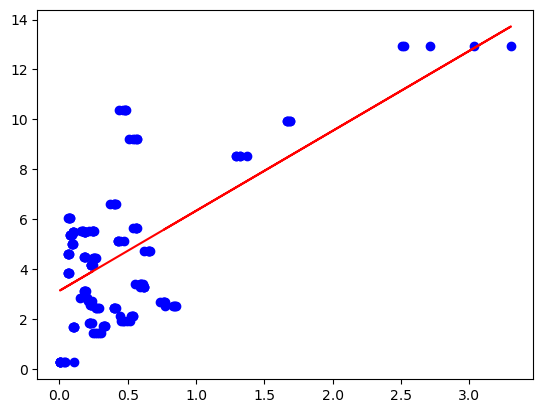

In [10]:
plt.scatter(ke_test_data, ee_test, color ='blue') 
plt.plot(ke_test_data, ee_pred, color ='red') 
  
plt.show() 

In [11]:
hr_learnDf = hr_df[~hr_df['Subject'].str.contains(r'09|10', regex=True)]
hr_testDf = hr_df[hr_df['Subject'].str.contains(r'09|10', regex=True)]
print(hr_learnDf)
print(hr_testDf)

hr_learn_data = hr_learnDf[['HR']]
ee_learn_data = hr_learnDf['EE']

model = LinearRegression()
model.fit(hr_learn_data, ee_learn_data)

hr_test_data = hr_testDf[['HR']]
ee_pred = model.predict(hr_test_data)
ee_test = hr_testDf['EE']

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Evaluate
mse = mean_squared_error(ee_test, ee_pred)
r2 = r2_score(ee_test, ee_pred)

print("Mean Squared Error:", mse)
print("R-squared Score:", r2)


plt.scatter(hr_test_data, ee_test, color ='blue') 
plt.plot(hr_test_data, ee_pred, color ='red') 
plt.show() 

KeyError: 'Subject'

In [12]:
print(hr_df[hr_df['Subject'] == 'Subject06'])
print(ke_df[ke_df['Subject'] == 'Subject06'])


KeyError: 'Subject'

In [13]:
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
# LR_df = LR_df.iloc[:, 1:4]

x = LR_df[["KE", "HR","Sex","Height","Weight"]]  
y = LR_df["EE"] 

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Mean Squared Error: 2.7145566516237305
R^2 Score: 0.7351192152473338
Coefficients: [ 1.69468491  0.08552517 -0.5154203  -0.47963208  0.04561962]
Intercept: -0.5568136261766963


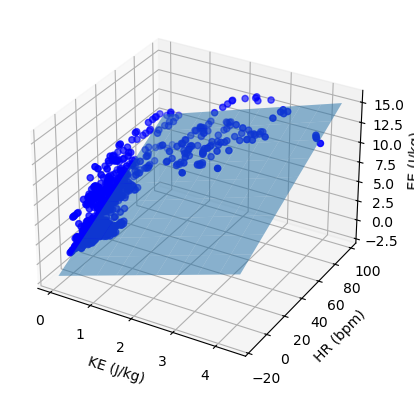

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_test['KE'], x_test['HR'], y_test, c='b', marker='o')

x_range = np.linspace(x_test['KE'].min(), x_test['KE'].max(), 10)
y_range = np.linspace(x_test['HR'].min(), x_test['HR'].max(), 10)
X_plane, Y_plane = np.meshgrid(x_range, y_range)
Z_plane = model.intercept_ + model.coef_[0] * X_plane + model.coef_[1] * Y_plane

ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.5)

ax.set_xlabel('KE (J/kg)')
ax.set_ylabel('HR (bpm)')
ax.set_zlabel('EE (J/kg)')

plt.show()

In [15]:
# SVR train 80%, test 20%
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
# Keep only relevant columns (drop "Activity")
LR_df = LR_df[["KE", "HR", "Subject", "EE"]]

# Convert "Subject" (a string) to numeric using Label Encoding
le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

# Define features and target
x = LR_df.drop(columns=["EE"])  # All columns except EE
y = LR_df["EE"]  

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train LinearSVR model
model = LinearSVR(random_state=42, max_iter=1000000)
model.fit(x_train, y_train)

# Make predictions
y_pred = model.predict(x_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")


Mean Squared Error: 3.3420194399310312
R^2 Score: 0.7060300382836485
Coefficients: [1.59298176 0.08448714 0.04300564]
Intercept: [1.25063528]


In [16]:
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR", "Subject", "EE"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearSVR(random_state=42, max_iter=1000000)
model.fit(x_train, y_train)

y_testPred = model.predict(x_test)
y_trainPred = model.predict(x_train)

# Evaluatation
mseTest = mean_squared_error(y_test, y_testPred)
mseTrain = mean_squared_error(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)

# Print results
print(f"Train Mean Squared Error: {mseTrain}")
print(f"Test Mean Squared Error: {mseTest}")
print(f"Train R^2 Score: {r2train}")
print(f"Test R^2 Score: {r2test}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")


Train Mean Squared Error: 2.6694018072509484
Test Mean Squared Error: 3.3420194399310312
Train R^2 Score: 0.7084819076536352
Test R^2 Score: 0.7060300382836485
Coefficients: [1.59298176 0.08448714 0.04300564]
Intercept: [1.25063528]


In [17]:
# SVR train 8, test 2
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
train_mask = LR_df["Subject"].isin(range(0, 8))  # Subjects 1-8 for training
x_train, y_train = x[train_mask], y[train_mask]
x_test, y_test = x[~train_mask], y[~train_mask]  # Subjects 9-10 for testing

# print(x_train)
model = LinearSVR(random_state=42, max_iter=1000000)
model.fit(x_train, y_train)

y_testPred = model.predict(x_test)
y_trainPred = model.predict(x_train)

# Evaluatation
mseTest = mean_squared_error(y_test, y_testPred)
mseTrain = mean_squared_error(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)

print(f"Train Mean Squared Error: {mseTrain}")
print(f"Test Mean Squared Error: {mseTest}")
print(f"Train R^2 Score: {r2train}")
print(f"Test R^2 Score: {r2test}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")


Train Mean Squared Error: 2.2693221784863518
Test Mean Squared Error: 6.813934260429133
Train R^2 Score: 0.7741530995779129
Test R^2 Score: 0.11372991692479484
Coefficients: [ 0.30661379  0.09010099  0.07731011  0.11578785  1.19404156 -0.6093756
  0.0213594 ]
Intercept: [-2.54045533]


In [18]:
Lreg_C = 1.5 # Penalty parameter C of the error term
LregSVR = SVR(kernel='linear', C=Lreg_C,epsilon=0.1)
LregSVR.fit(x_train, y_train)
yR_pred = LregSVR.predict(x_train)

linreg = LinearRegression().fit(x_train, y_train)
yL_pred = linreg.predict(x_train)

train_score=LregSVR.score(x_train, y_train)
test_score=LregSVR.score(x_test, y_test)
Ltrain_score=linreg.score(x_train, y_train)
Ltest_score=linreg.score(x_test, y_test)

print(f"Train Score: {train_score}")
print(f"Test Score: {test_score}")
print(f"Linear Train Score: {Ltrain_score}")
print(f"Linear Test Score: {Ltest_score}")



Train Score: 0.7773546002165961
Test Score: 0.20004406087565696
Linear Train Score: 0.7823213170726403
Linear Test Score: 0.36177885147789024


In [19]:
# SVR train 8, test 2
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR","Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE","Subject"]) 
y = LR_df["EE"]  

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# print(x_train)
model = LinearSVR(random_state=42, max_iter=1000000)
model.fit(x_train, y_train)

y_testPred = model.predict(x_test)
y_trainPred = model.predict(x_train)

# Evaluatation
mseTest = mean_squared_error(y_test, y_testPred)
mseTrain = mean_squared_error(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)

print(f"Train Mean Squared Error: {mseTrain}")
print(f"Test Mean Squared Error: {mseTest}")
print(f"Train R^2 Score: {r2train}")
print(f"Test R^2 Score: {r2test}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")


Train Mean Squared Error: 2.4112325758636217
Test Mean Squared Error: 2.9936766865170754
Train R^2 Score: 0.7366758654280429
Test R^2 Score: 0.7366708851505902
Coefficients: [ 0.38933995  0.08365345  0.08949748 -0.40560522 -1.5922719   0.05815013]
Intercept: [-3.10060153]


In [20]:
Lreg_C = 1.5 # Penalty parameter C of the error term
LregSVR = SVR(kernel='linear', C=Lreg_C,epsilon=0.1)
LregSVR.fit(x_train, y_train)
yR_pred = LregSVR.predict(x_train)

linreg = LinearRegression().fit(x_train, y_train)
yL_pred = linreg.predict(x_train)

train_score=LregSVR.score(x_train, y_train)
test_score=LregSVR.score(x_test, y_test)
Ltrain_score=linreg.score(x_train, y_train)
Ltest_score=linreg.score(x_test, y_test)

print(f"Train Score: {train_score}")
print(f"Test Score: {test_score}")
print(f"Linear Train Score: {Ltrain_score}")
print(f"Linear Test Score: {Ltest_score}")



Train Score: 0.7384639381544477
Test Score: 0.7440761193184313
Linear Train Score: 0.7424456995585085
Linear Test Score: 0.7453706342839541


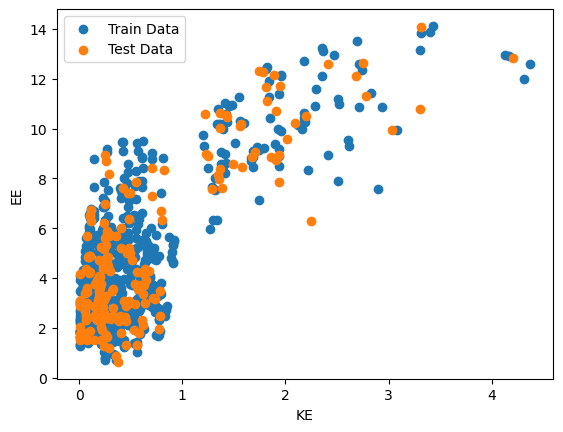

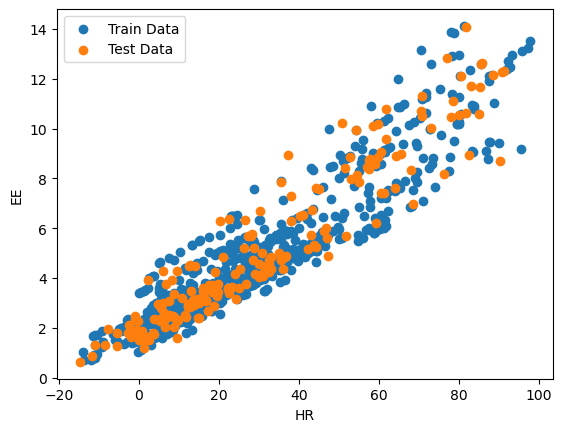

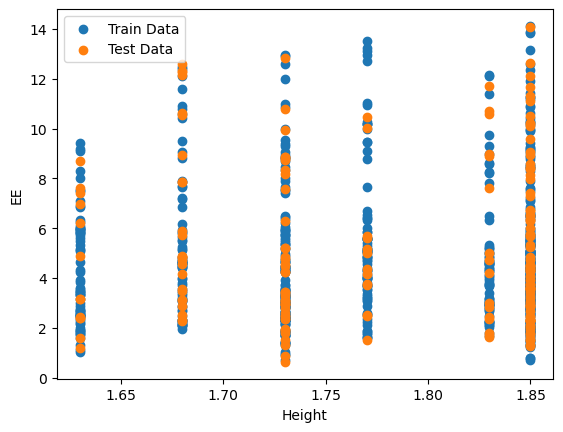

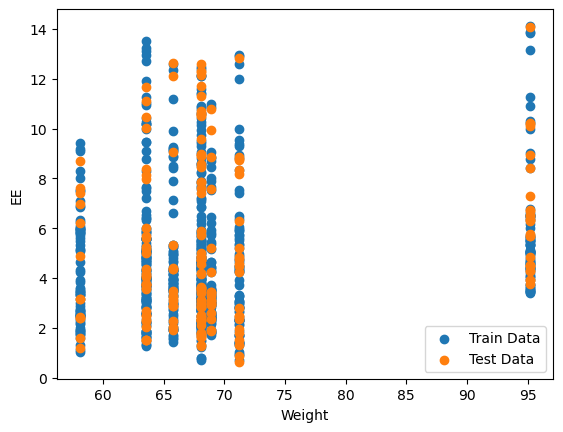

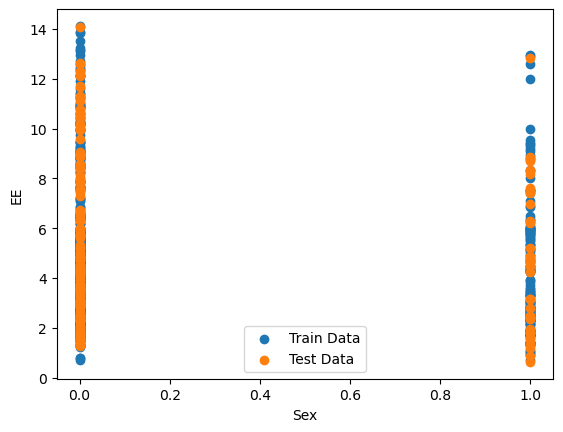

In [21]:
plt.scatter(x_train['KE'], y_trainPred, label='Train Data')
plt.scatter(x_test['KE'], y_testPred, label='Test Data')
plt.xlabel('KE')
plt.ylabel('EE')
plt.legend()
plt.show()

plt.scatter(x_train['HR'], y_trainPred, label='Train Data')
plt.scatter(x_test['HR'], y_testPred, label='Test Data')
plt.xlabel('HR')
plt.ylabel('EE')
plt.legend()
plt.show()

plt.scatter(x_train['Height'], y_trainPred, label='Train Data')
plt.scatter(x_test['Height'], y_testPred, label='Test Data')
plt.xlabel('Height')
plt.ylabel('EE')
plt.legend()
plt.show()

plt.scatter(x_train['Weight'], y_trainPred, label='Train Data')
plt.scatter(x_test['Weight'], y_testPred, label='Test Data')
plt.xlabel('Weight')
plt.ylabel('EE')
plt.legend()
plt.show()

plt.scatter(x_train['Sex'], y_trainPred, label='Train Data')
plt.scatter(x_test['Sex'], y_testPred, label='Test Data')
plt.xlabel('Sex')
plt.ylabel('EE')
plt.legend()
plt.show()

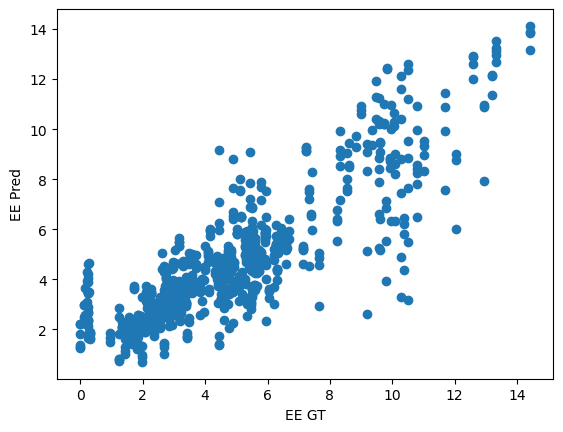

In [22]:
plt.scatter(y_train, y_trainPred, label='Test Data')
plt.xlabel('EE GT')
plt.ylabel('EE Pred')
plt.show()

In [23]:
# SVR train 8, test 2

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
train_mask = LR_df["Subject"].isin(range(0, 8))  # Subjects 1-8 for training
x_train, y_train = x[train_mask], y[train_mask]
x_test, y_test = x[~train_mask], y[~train_mask]  # Subjects 9-10 for testing

# print(x_train)
model = SVR(kernel='rbf')
model.fit(x_train, y_train)

y_testPred = model.predict(x_test)
y_trainPred = model.predict(x_train)

# Evaluatation
mseTest = mean_squared_error(y_test, y_testPred)
mseTrain = mean_squared_error(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)

print(f"Train Mean Squared Error: {mseTrain}")
print(f"Test Mean Squared Error: {mseTest}")
print(f"Train R^2 Score: {r2train}")
print(f"Test R^2 Score: {r2test}")
# print(f"Coefficients: {model.coef_}")
# print(f"Intercept: {model.intercept_}") 


Train Mean Squared Error: 2.184860908100824
Test Mean Squared Error: 3.84131999306622
Train R^2 Score: 0.7825588324893176
Test R^2 Score: 0.5003698510647449


In [24]:
Lreg_C = 1.5 # Penalty parameter C of the error term
LregSVR = SVR(kernel='rbf', C=Lreg_C, epsilon=0.1)
LregSVR.fit(x_train, y_train)
yR_pred = LregSVR.predict(x_train)

linreg = LinearRegression().fit(x_train, y_train)
yL_pred = linreg.predict(x_train)

train_score=LregSVR.score(x_train, y_train)
test_score=LregSVR.score(x_test, y_test)
Ltrain_score=linreg.score(x_train, y_train)
Ltest_score=linreg.score(x_test, y_test)

print(f"Train Score: {train_score}")
print(f"Test Score: {test_score}")
print(f"Linear Train Score: {Ltrain_score}")
print(f"Linear Test Score: {Ltest_score}")



Train Score: 0.7894949421879195
Test Score: 0.5244449430638056
Linear Train Score: 0.7823213170726403
Linear Test Score: 0.36177885147789024


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error


filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 

LR_df = LR_df[["KE", "HR","Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
train_mask = LR_df["Subject"].isin(range(0, 8))  # Subjects 1-8 for training
x_train, y_train = x[train_mask], y[train_mask]
x_test, y_test = x[~train_mask], y[~train_mask]  # Subjects 9-10 for testing

# Create KNN Regressor with k=5
knn_regressor = KNeighborsRegressor(n_neighbors=15)

# Train the model
knn_regressor.fit(x_train, y_train)

# Make predictions
y_pred = knn_regressor.predict(x_test)

# Evaluate performance using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"KNN Regression MSE: {mse:.2f}")


KNN Regression MSE: 3.89


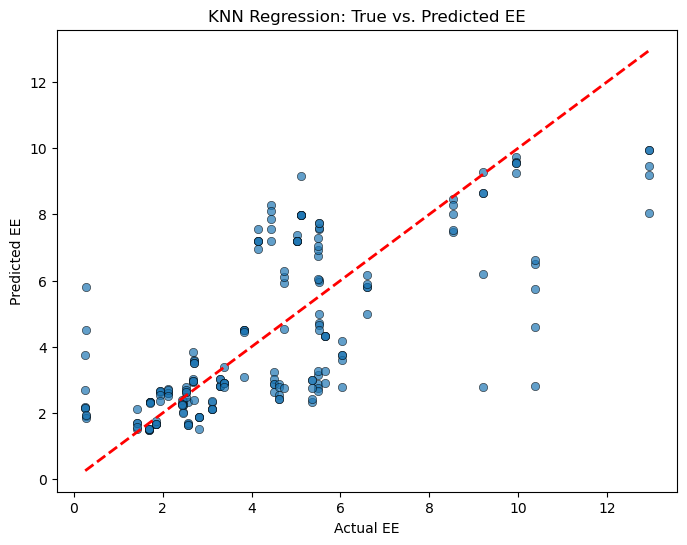

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Scatter plot: True vs. Predicted EE values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, edgecolor="k", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Ideal 1:1 line
plt.xlabel("Actual EE")
plt.ylabel("Predicted EE")
plt.title("KNN Regression: True vs. Predicted EE")
plt.show()


Decision Tree Regression MSE: 3.23
Decision Tree Regression R² Score: 0.58


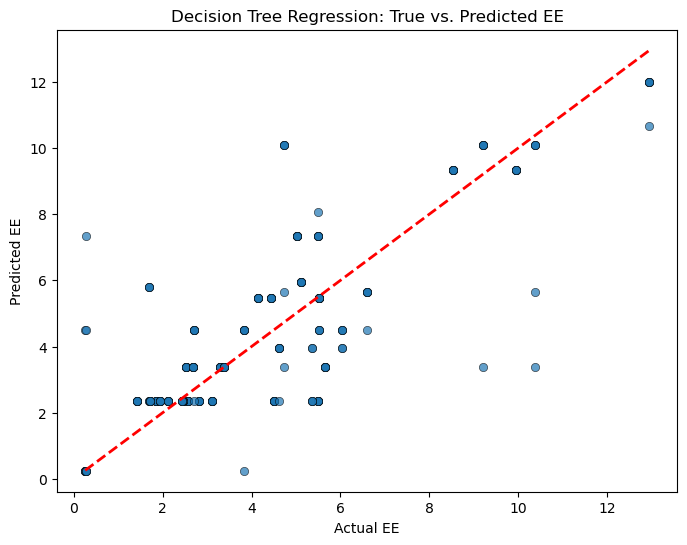

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR","Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
train_mask = LR_df["Subject"].isin(range(0, 8))  # Subjects 1-8 for training
X_train, y_train = x[train_mask], y[train_mask]
X_test, y_test = x[~train_mask], y[~train_mask]  # Subjects 9-10 for testing

# Create Decision Tree Regressor
dt_regressor = DecisionTreeRegressor(max_depth=5, random_state=42)

# Train the model
dt_regressor.fit(X_train, y_train)

# Make predictions
y_pred = dt_regressor.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Decision Tree Regression MSE: {mse:.2f}")
print(f"Decision Tree Regression R² Score: {r2:.2f}")

# --- Visualization ---

# Scatter plot: True vs. Predicted EE values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, edgecolor="k", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Ideal 1:1 line
plt.xlabel("Actual EE")
plt.ylabel("Predicted EE")
plt.title("Decision Tree Regression: True vs. Predicted EE")
plt.show()

Lasso Regression MSE: 3.35
Lasso Regression R² Score: 0.56
Coefficients: [ 0.          0.0807705   0.12714893  0.0234522   0.         -0.
  0.04412624]


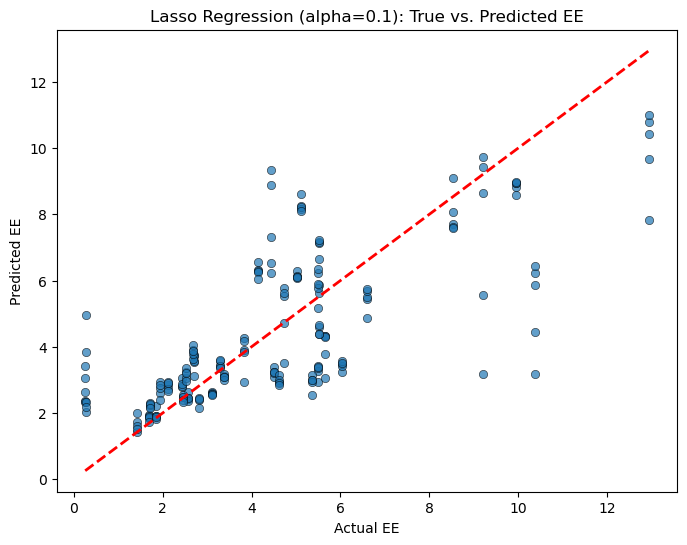

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score


filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR","Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
train_mask = LR_df["Subject"].isin(range(0, 8))  # Subjects 1-8 for training
X_train, y_train = x[train_mask], y[train_mask]
X_test, y_test = x[~train_mask], y[~train_mask]  # Subjects 9-10 for testing

# Create and train Lasso regression model
alpha = 0.1  
lasso_regressor = Lasso(alpha=alpha)
lasso_regressor.fit(X_train, y_train)

# Make predictions
y_pred = lasso_regressor.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Lasso Regression MSE: {mse:.2f}")
print(f"Lasso Regression R² Score: {r2:.2f}")
print(f"Coefficients: {lasso_regressor.coef_}")


# Scatter plot: True vs. Predicted EE values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, edgecolor="k", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  
plt.xlabel("Actual EE")
plt.ylabel("Predicted EE")
plt.title(f"Lasso Regression (alpha={alpha}): True vs. Predicted EE")
plt.show()

Ridge Regression (alpha=0.1)
Train MSE: 2.19, Train RMSE: 1.48, Train R²: 0.7823
Test MSE: 4.91, Test RMSE: 2.22, Test R²: 0.3608


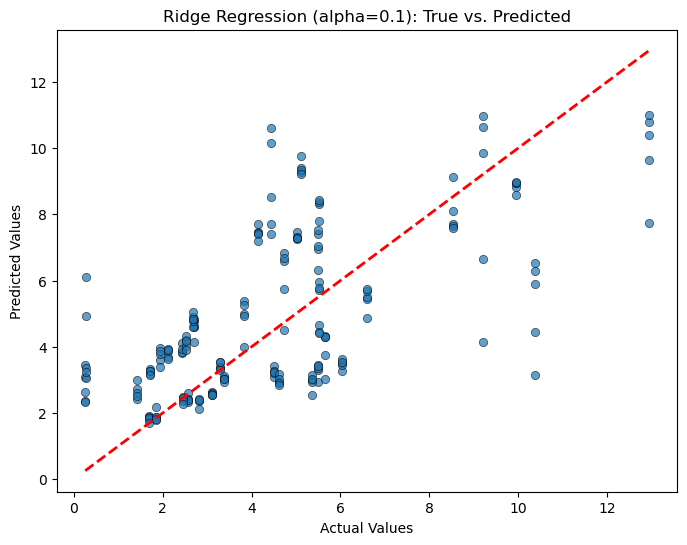

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR","Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject

x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
train_mask = LR_df["Subject"].isin(range(0, 8))  # Subjects 1-8 for training
X_train, y_train = x[train_mask], y[train_mask]
X_test, y_test = x[~train_mask], y[~train_mask]  # Subjects 9-10 for testing

# Create and train ridge regression model
alpha = 0.1 # Regularization strength
ridge_regressor = Ridge(alpha=alpha)
ridge_regressor.fit(X_train, y_train)

# Make predictions
y_train_pred = ridge_regressor.predict(X_train)
y_test_pred = ridge_regressor.predict(X_test)

# Calculate metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Ridge Regression (alpha={alpha})")
print(f"Train MSE: {train_mse:.2f}, Train RMSE: {train_rmse:.2f}, Train R²: {train_r2:.4f}")
print(f"Test MSE: {test_mse:.2f}, Test RMSE: {test_rmse:.2f}, Test R²: {test_r2:.4f}")


# Scatter plot: True vs. Predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred, edgecolor="k", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Ridge Regression (alpha={alpha}): True vs. Predicted")
plt.show()



In [30]:
# SVR train 8, test 2
from sklearn.inspection import permutation_importance
filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all") 
LR_df = LR_df[["KE", "HR","Accel", "Subject", "EE","Sex","Height","Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  # Assigns numbers to each unique subject


x = LR_df.drop(columns=["EE"]) # All columns except EE
y = LR_df["EE"]  

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
train_mask = LR_df["Subject"].isin(range(0, 8))  # Subjects 1-8 for training
x_train, y_train = x[train_mask], y[train_mask]
x_test, y_test = x[~train_mask], y[~train_mask]  # Subjects 9-10 for testing

# print(x_train)
model = SVR(kernel='rbf')
model.fit(x_train, y_train)

y_testPred = model.predict(x_test)
y_trainPred = model.predict(x_train)

# Evaluatation
mseTest = mean_squared_error(y_test, y_testPred)
mseTrain = mean_squared_error(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)

print(f"Train Mean Squared Error: {mseTrain}")
print(f"Test Mean Squared Error: {mseTest}")
print(f"Train R^2 Score: {r2train}")
print(f"Test R^2 Score: {r2test}")
# print(f"Coefficients: {model.coef_}")
# print(f"Intercept: {model.intercept_}") 

feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

# Show results
print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")

Train Mean Squared Error: 2.184860908100824
Test Mean Squared Error: 3.84131999306622
Train R^2 Score: 0.7825588324893176
Test R^2 Score: 0.5003698510647449
---------------
FEAT IMPORTANCE
KE: 0.0008 ± 0.0002
HR: 0.8502 ± 0.0823
Accel: 0.1456 ± 0.0220
Subject: -0.0048 ± 0.0010
Sex: -0.0016 ± 0.0003
Height: -0.0000 ± 0.0000
Weight: 0.1176 ± 0.0195


In [62]:
# SVR Linear train 8, test 2: MinMaxScaler
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Height", "Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0, 8))  
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='linear')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")


Train Mean Squared Error: 2.2400
Test Mean Squared Error: 4.6618
Train R^2 Score: 0.7771
Test R^2 Score: 0.3937
---------------
FEAT IMPORTANCE
KE: 0.0341 ± 0.0058
HR: 0.6527 ± 0.0756
Accel: 0.1510 ± 0.0201
Sex: -0.1375 ± 0.0284
Height: 0.0573 ± 0.0077
Weight: 0.0868 ± 0.0114


In [63]:
# SVR Linear train 8, test 2: MinMaxScaler
# Removing features with negative importance
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Height", "Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject","Sex"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0, 8))  
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='linear')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")

Train Mean Squared Error: 2.3099
Test Mean Squared Error: 3.4986
Train R^2 Score: 0.7701
Test R^2 Score: 0.5449
---------------
FEAT IMPORTANCE
KE: 0.0367 ± 0.0054
HR: 0.7211 ± 0.0696
Accel: 0.1427 ± 0.0176
Height: 0.0022 ± 0.0004
Weight: 0.0750 ± 0.0122


In [64]:
# SVR rbf train 8, test 2: MinMaxScaler
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Height", "Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0, 8))  
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='rbf')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")


Train Mean Squared Error: 1.7743
Test Mean Squared Error: 4.3252
Train R^2 Score: 0.8234
Test R^2 Score: 0.4374
---------------
FEAT IMPORTANCE
KE: 0.0595 ± 0.0106
HR: 0.5160 ± 0.0611
Accel: 0.1559 ± 0.0239
Sex: -0.1258 ± 0.0208
Height: 0.0179 ± 0.0178
Weight: 0.0831 ± 0.0187


In [60]:
# SVR RBF train 8, test 2: MinMaxScaler
# Removing features with negative importance
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/KE-HR-EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Height", "Weight"]]

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject","Sex"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0, 8))  
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='rbf')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")

Train Mean Squared Error: 1.7601
Test Mean Squared Error: 2.8512
Train R^2 Score: 0.8248
Test R^2 Score: 0.6291
---------------
FEAT IMPORTANCE
KE: 0.0666 ± 0.0093
HR: 0.5676 ± 0.0591
Accel: 0.2089 ± 0.0278
Height: 0.0722 ± 0.0185
Weight: 0.0984 ± 0.0186


In [8]:
# SVR Linear train 8, test 2: MinMaxScaler
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Height", "Weight","EMG2","EMG3", "EMG4", "EMG5", "EMG6", "EMG7", "EMG8", "EMG9", "EMG10", "EMG11", "EMG12", "EMG13", "EMG14", "EMG15", "EMG16","EMG17"]]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0,8))
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='linear')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")


Train Mean Squared Error: 0.9926
Test Mean Squared Error: 1.6056
Train R^2 Score: 0.9025
Test R^2 Score: 0.6781
---------------
FEAT IMPORTANCE
KE: -0.0293 ± 0.0037
HR: 0.6997 ± 0.0513
Accel: -0.0537 ± 0.0075
Sex: 0.1386 ± 0.0204
Height: -0.0327 ± 0.0101
Weight: -0.0259 ± 0.0067
EMG2: -0.0010 ± 0.0008
EMG3: -0.0156 ± 0.0042
EMG4: 0.0808 ± 0.0111
EMG5: -0.0001 ± 0.0000
EMG6: -0.0504 ± 0.0058
EMG7: 0.0065 ± 0.0009
EMG8: -0.0182 ± 0.0098
EMG9: -0.0191 ± 0.0039
EMG10: -0.0010 ± 0.0001
EMG11: -0.0076 ± 0.0012
EMG12: -0.0007 ± 0.0025
EMG13: -0.0749 ± 0.0119
EMG14: -0.0386 ± 0.0070
EMG15: -0.0028 ± 0.0005
EMG16: 0.0069 ± 0.0016
EMG17: -0.0069 ± 0.0008


In [3]:
# SVR Linear train 8, test 2: MinMaxScaler
# Removing features with negative importance
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Weight","EMG2","EMG3", "EMG4", "EMG5", "EMG7","EMG8", "EMG9", "EMG10", "EMG11", "EMG12", "EMG13", "EMG14", "EMG15", "EMG16","EMG17"]]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject","Sex"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0, 8))  
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='linear')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")

Train Mean Squared Error: 1.1051
Test Mean Squared Error: 0.9964
Train R^2 Score: 0.8891
Test R^2 Score: 0.8696
---------------
FEAT IMPORTANCE
KE: 0.0519 ± 0.0052
HR: 0.5293 ± 0.0603
Accel: 0.0470 ± 0.0074
Weight: -0.0097 ± 0.0047
EMG2: -0.0026 ± 0.0006
EMG3: 0.0008 ± 0.0009
EMG4: 0.0207 ± 0.0036
EMG5: 0.0071 ± 0.0027
EMG7: 0.0083 ± 0.0029
EMG8: 0.0176 ± 0.0046
EMG9: -0.0006 ± 0.0006
EMG10: -0.0006 ± 0.0003
EMG11: 0.0006 ± 0.0033
EMG12: -0.0025 ± 0.0034
EMG13: 0.0005 ± 0.0006
EMG14: 0.0517 ± 0.0080
EMG15: 0.0187 ± 0.0033
EMG16: 0.0022 ± 0.0024
EMG17: -0.0022 ± 0.0008


In [4]:
# SVR rbf train 8, test 2: MinMaxScaler
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex", "Height", "Weight","EMG2","EMG3", "EMG4", "EMG5", "EMG6", "EMG7", "EMG8", "EMG9", "EMG10", "EMG11", "EMG12", "EMG13", "EMG14", "EMG15", "EMG16","EMG17"]]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0, 8))  
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='rbf')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")


Train Mean Squared Error: 0.5380
Test Mean Squared Error: 1.7831
Train R^2 Score: 0.9460
Test R^2 Score: 0.7667
---------------
FEAT IMPORTANCE
KE: 0.0411 ± 0.0054
HR: 0.3368 ± 0.0404
Accel: 0.0850 ± 0.0128
Sex: 0.0260 ± 0.0071
Height: -0.0038 ± 0.0083
Weight: -0.0221 ± 0.0084
EMG2: 0.0000 ± 0.0011
EMG3: 0.0025 ± 0.0038
EMG4: 0.0075 ± 0.0037
EMG5: 0.0444 ± 0.0110
EMG6: 0.0093 ± 0.0048
EMG7: 0.0255 ± 0.0058
EMG8: 0.0284 ± 0.0057
EMG9: 0.0253 ± 0.0040
EMG10: 0.0008 ± 0.0013
EMG11: 0.0119 ± 0.0056
EMG12: 0.0359 ± 0.0095
EMG13: 0.0307 ± 0.0076
EMG14: 0.0488 ± 0.0092
EMG15: 0.0167 ± 0.0059
EMG16: 0.0225 ± 0.0040
EMG17: 0.0157 ± 0.0032


In [5]:
# SVR rbf train 8, test 2: MinMaxScaler
np.set_printoptions(precision=3, suppress=True)
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

filePath = "/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/EE_Dataset.csv"
LR_df = pd.read_csv(filePath)
LR_df = LR_df.dropna(how="all")
LR_df = LR_df[["KE", "HR", "Accel", "Subject", "EE", "Sex","EMG3", "EMG4", "EMG5", "EMG6", "EMG7", "EMG8", "EMG9", "EMG10", "EMG11", "EMG12", "EMG13", "EMG14", "EMG15", "EMG16","EMG17"]]
LR_df.fillna(0, inplace=True)

le = LabelEncoder()
LR_df["Subject"] = le.fit_transform(LR_df["Subject"])  

x = LR_df.drop(columns=["EE","Subject"])
y = LR_df["EE"]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(x)
scaled_df = pd.DataFrame(scaled_data, columns=x.columns)

train_mask = LR_df["Subject"].isin(range(0, 8))  
x_train, y_train = scaled_df[train_mask.values], y[train_mask]
x_test, y_test = scaled_df[~train_mask.values], y[~train_mask]

model = SVR(kernel='rbf')
model.fit(x_train, y_train)

y_trainPred = model.predict(x_train)
y_testPred = model.predict(x_test)

mseTrain = mean_squared_error(y_train, y_trainPred)
mseTest = mean_squared_error(y_test, y_testPred)
r2train = r2_score(y_train, y_trainPred)
r2test = r2_score(y_test, y_testPred)

print(f"Train Mean Squared Error: {mseTrain:.4f}")
print(f"Test Mean Squared Error: {mseTest:.4f}")
print(f"Train R^2 Score: {r2train:.4f}")
print(f"Test R^2 Score: {r2test:.4f}")

# Permutation importance
feat_importance = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)

print('---------------')
print('FEAT IMPORTANCE')
for i, col in enumerate(x.columns):
    print(f"{col}: {feat_importance.importances_mean[i]:.4f} ± {feat_importance.importances_std[i]:.4f}")


Train Mean Squared Error: 0.6778
Test Mean Squared Error: 1.8129
Train R^2 Score: 0.9320
Test R^2 Score: 0.7628
---------------
FEAT IMPORTANCE
KE: 0.0847 ± 0.0118
HR: 0.3733 ± 0.0476
Accel: 0.1084 ± 0.0140
Sex: 0.0396 ± 0.0070
EMG3: 0.0323 ± 0.0081
EMG4: 0.0154 ± 0.0056
EMG5: 0.0548 ± 0.0118
EMG6: 0.0421 ± 0.0094
EMG7: 0.0308 ± 0.0067
EMG8: 0.0589 ± 0.0057
EMG9: 0.0429 ± 0.0041
EMG10: 0.0030 ± 0.0008
EMG11: 0.0211 ± 0.0097
EMG12: 0.0978 ± 0.0219
EMG13: 0.0292 ± 0.0054
EMG14: 0.0616 ± 0.0113
EMG15: 0.0290 ± 0.0096
EMG16: 0.0338 ± 0.0039
EMG17: 0.0300 ± 0.0042
